In [1]:
!pip install git+https://github.com/huggingface/diffusers
!pip install -U transformers accelerate sentencepiece

  Cloning https://github.com/huggingface/diffusers to /tmp/pip-req-build-tdztidmw
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-tdztidmw
  Resolved https://github.com/huggingface/diffusers to commit e747fe4a942ce379d73a975a82f9e4c484c74ba2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.37.0.dev0-py3-none-any.whl size=5000551 sha256=1e635185876d5306367f0795bea29944964fa85368c2ba2e42158c2750c81a52
  Stored in directory: /tmp/pip-ephem-wheel-cache-bvh7zqcc/wheels/90/d4/44/a58bc00fb405fefb633b0d9d2307f6e3aec6cc1775d82555d3
Successfully built diffusers
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.36.0
    Uninstalling diffusers-0.36.0:
      Successfully uninstalled diffusers-0.36.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 113.8 MB/s et

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
project_path = '/content/drive/MyDrive/CASteer_CV'
os.chdir(project_path)

print("Current Working Directory:", os.getcwd())
print("Files in this directory:", os.listdir())

Mounted at /content/drive
Current Working Directory: /content/drive/MyDrive/CASteer_CV
Files in this directory: ['compute_steering_vectors.py', 'generate_casteer.py', 'imagenet_classes.txt', 'construct_prompts.py', 'README.md', '__pycache__', 'controller.py', 'casteer_raw_v1.ipynb', 'cache', 'steering_vectors', 'construct_prompts_mod.py']


In [2]:
import os
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Navigate to your project folder (CHANGE THIS PATH TO YOUR ACTUAL FOLDER)
project_folder = '/content/drive/MyDrive/CASteer_CV'
os.chdir(project_folder)
print(f"Working directory set to: {os.getcwd()}")

# 3. FIX controller.py: Add the missing helper function automatically
# We read the file, check if the function is missing, and add it.
controller_path = "controller.py"

with open(controller_path, 'r') as f:
    content = f.read()

missing_func_code = """
def _chunked_feed_forward(ff: torch.nn.Module, hidden_states: torch.Tensor, chunk_dim: int, chunk_size: int):
    if hidden_states.shape[chunk_dim] % chunk_size != 0:
        raise ValueError(f"`hidden_states` dimension to be chunked: {hidden_states.shape[chunk_dim]} has to be divisible by chunk size: {chunk_size}")
    padding_chunk_size = hidden_states.shape[chunk_dim] // chunk_size
    chunk_params = {"dim": chunk_dim, "start_dim": 0, "length": padding_chunk_size}
    if not chunk_dim == 0:
        chunk_params["start_dim"] = 1
        chunk_params["length"] = 1
    total_chunk_size = chunk_size * padding_chunk_size
    if total_chunk_size == 0:
        return ff(hidden_states)
    ff_output = torch.zeros_like(hidden_states)
    for i in range(chunk_size):
        chunk_hidden_states = torch.narrow(hidden_states, chunk_params["dim"], chunk_params["start_dim"] + i * chunk_params["length"], chunk_params["length"])
        chunk_ff_output = ff(chunk_hidden_states)
        if chunk_dim == 0:
            ff_output[i * padding_chunk_size : (i + 1) * padding_chunk_size] = chunk_ff_output
        elif chunk_dim == 1:
            ff_output[:, i * padding_chunk_size : (i + 1) * padding_chunk_size] = chunk_ff_output
    return ff_output
"""

if "_chunked_feed_forward" not in content:
    print("Fixing controller.py...")
    # Insert the function before the register_vector_control function
    new_content = missing_func_code + "\n" + content
    with open(controller_path, 'w') as f:
        f.write(new_content)
    print("controller.py fixed successfully!")
else:
    print("controller.py is already fixed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory set to: /content/drive/MyDrive/CASteer_CV
controller.py is already fixed.


In [3]:
import torch
from diffusers import StableDiffusionPipeline

# Configuration
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "CompVis/stable-diffusion-v1-4"

# Load Pipeline
print("Loading model... this takes about 30-60 seconds...")
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    variant="fp16"
).to(device)

print("Model loaded!")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading model... this takes about 30-60 seconds...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!


In [ ]:
import numpy as np
import pickle
from collections import defaultdict
from tqdm import tqdm

# Local imports (using only what ACTUALLY exists)
from construct_prompts_mod import get_prompts_concrete, get_prompts_style, get_prompts_human_related
from controller import VectorStore, register_vector_control

# --- CONFIGURATION ---
class Config:
    mode = 'concrete'          # choices: 'concrete', 'human-related', 'style'
    concept_pos = 'food'
    concept_neg = None
    num_denoising_steps = 50
    save_dir = 'steering_vectors'

args = Config()
# ---------------------

NUM_PROMPTS = 50

# 1. Get Prompts
if args.mode == 'concrete':
    prompts_pos, prompts_neg = get_prompts_concrete(num=NUM_PROMPTS, concept_pos=args.concept_pos, concept_neg=args.concept_neg)
elif args.mode == 'human-related':
    prompts_pos, prompts_neg = get_prompts_human_related(num=NUM_PROMPTS, concept_pos=args.concept_pos, concept_neg=args.concept_neg)
elif args.mode == 'style':
    prompts_pos, prompts_neg = get_prompts_style(num=NUM_PROMPTS, concept_pos=args.concept_pos, concept_neg=args.concept_neg)

print(f"Computing vectors for '{args.concept_pos}' ({len(prompts_pos)} pairs)...")

# 2. Compute Activations
pos_vectors = []
neg_vectors = []
seed = 0

# We use a generator for consistency
generator = torch.Generator(device=device).manual_seed(seed)

for i, (prompt_pos, prompt_neg) in enumerate(tqdm(zip(prompts_pos, prompts_neg), total=len(prompts_pos))):
    print('Prompt pair number', i, 'out of', len(prompts_pos))
    print('Positive prompt:', prompt_pos)
    print('Negative prompt', prompt_neg)

    # Run Positive
    controller = VectorStore()
    controller.steer = False
    register_vector_control(pipe.unet, controller)

    with torch.inference_mode():
        pipe(prompt_pos, num_inference_steps=args.num_denoising_steps, generator=generator)
    pos_vectors.append(controller.vector_store)

    # Run Negative
    controller = VectorStore()
    controller.steer = False
    register_vector_control(pipe.unet, controller)

    with torch.inference_mode():
        pipe(prompt_neg, num_inference_steps=args.num_denoising_steps, generator=generator)
    neg_vectors.append(controller.vector_store)

# 3. Calculate Mean Difference (The Steering Vector)
print("Averaging vectors...")
steering_vectors = {}

for denoising_step in range(0, args.num_denoising_steps):
    steering_vectors[denoising_step] = defaultdict(list)

    for key in ['up', 'down', 'mid']:
        # Check if we have data for this layer type
        if len(pos_vectors[0][denoising_step][key]) == 0:
            continue

        for layer_num in range(len(pos_vectors[0][denoising_step][key])):

            # Gather all samples for this specific layer & step
            pos_vectors_layer = [pos_vectors[i][denoising_step][key][layer_num] for i in range(len(pos_vectors))]
            pos_vectors_avg = np.mean(pos_vectors_layer, axis=0)

            neg_vectors_layer = [neg_vectors[i][denoising_step][key][layer_num] for i in range(len(neg_vectors))]
            neg_vectors_avg = np.mean(neg_vectors_layer, axis=0)

            # Compute difference and normalize
            steering_vector = pos_vectors_avg - neg_vectors_avg
            steering_vector = steering_vector / (np.linalg.norm(steering_vector) + 1e-8) # added small epsilon for safety

            steering_vectors[denoising_step][key].append(steering_vector)

# 4. Save
if not os.path.exists(args.save_dir):
    os.makedirs(args.save_dir)

filename = f"{model_id.split('/')[-1]}_{args.concept_pos}_{args.concept_neg}.pickle" # e.g. stable-diffusion-v1-4_anime_None.pickle
save_path = os.path.join(args.save_dir, filename)

with open(save_path, 'wb') as handle:
    pickle.dump(steering_vectors, handle)

print(f"Steering vectors saved to: {save_path}")

Computing vectors for 'food' (50 pairs)...



  0%|          | 0/50 [00:00<?, ?it/s]

Prompt pair number 0 out of 50
Positive prompt: hoopskirt with food
Negative prompt hoopskirt


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

Prompt pair number 49 out of 50
Positive prompt: cannon with food
Negative prompt cannon


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]


100%|██████████| 50/50 [26:14<00:00, 31.49s/it]


Averaging vectors...
Steering vectors saved to: steering_vectors/stable-diffusion-v1-4_food_None.pickle


Loading vectors from: steering_vectors/stable-diffusion-v1-4_food_None.pickle
Generating: 'tree_with_fruits_hanging'...


  0%|          | 0/50 [00:00<?, ?it/s]

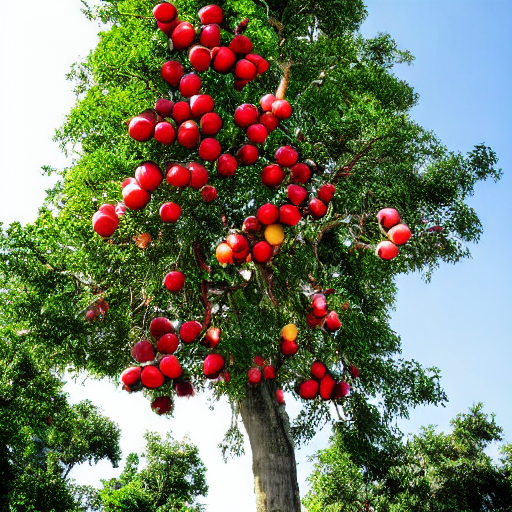

In [39]:
import pickle
from controller import VectorStore, register_vector_control

# --- GENERATION CONFIG ---
prompt = "tree with fruits hanging"
steering_strength = 3         # Equivalent to 'alpha'
steer_back = True             # Set True to erase concept
vectors_path = 'steering_vectors/stable-diffusion-v1-4_food_None.pickle'       # Uses the path we just saved to
# -------------------------

# 1. Load Vectors
print(f"Loading vectors from: {vectors_path}")
with open(vectors_path, 'rb') as handle:
    loaded_vectors = pickle.load(handle)

# 2. Setup Controller
controller = VectorStore(loaded_vectors, device=device)
controller.steer = True
controller.steer_only_up = False

if steer_back:
    controller.steer_back = True
    controller.beta = 2 # Default beta from original code
else:
    controller.steer_back = False
    controller.alpha = steering_strength

# 3. Register Controller
register_vector_control(pipe.unet, controller)

# 4. Generate
print(f"Generating: '{prompt.replace(" ", "_")}'...")
image = pipe(
    prompt,
    num_inference_steps=50,
    guidance_scale=7.5
).images[0]

# 5. Display
display(image)